In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
from infomap import Infomap

from collections import Counter
from collections import defaultdict
from sklearn.metrics import normalized_mutual_info_score, v_measure_score, jaccard_score

In [2]:
def structural_characterization(G_net):
    #read the file
    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        print("Graph is not connected, using largest connected component")

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

In [3]:
def represent_degree_distribution(G,scale='linear',rep='bars',weight=False):
    if(weight==False):
        degree_sequence=[G.degree(node) for node in G.nodes()]
    else:
        degree_sequence=[G.degree(node,weight='weight') for node in G.nodes()]
        
    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')

    if(weight==False):
        ax.set_xlabel('Degree',fontsize=15)
    else:
        ax.set_xlabel('Strength',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15)    


In [4]:
def fit_CCDF(G,weight=False):
    if(weight==False):
        degree_sequence=[G.degree(node) for node in G.nodes()]
    else:
        degree_sequence=[G.degree(node,weight='weight') for node in G.nodes()]

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')


    if(weight==False):
        ax.set_xlabel('$k$',fontsize=15)
        ax.set_ylabel('$CCDF(k)$',fontsize=15)
    else:
        ax.set_xlabel('$s$',fontsize=15)
        ax.set_ylabel('$CCDF(s)$',fontsize=15)
    

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()

In [5]:
def plot_network(G):
	fig,ax=plt.subplots(1,1,figsize=(20,20))
	### We fix the position of the nodes

	positions=nx.spring_layout(G,k=.2,weight='weight')

	## Size proportional to strength 
	sizes=[2*G.degree(node,weight='weight') for node in G.nodes()]

	## Set edge thickness proportional to the weight
	thickness=[.1*G.edges()[edge]['weight'] for edge in G.edges()]

	## We represent the network fixing the positions.
	nx.draw_networkx_nodes(G,pos=positions,node_size=sizes)
	nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness)
	plt.box(False)

In [6]:
def infomap_to_networkx_communities(G):
    im = Infomap(silent=True) 
    mapping = im.add_networkx_graph(G)
    im.run()

    infomap_partition = im.get_modules()
    community_dict = defaultdict(set)
    for node, community in infomap_partition.items():
        community_dict[community].add(mapping[node])
    
    return list(community_dict.values())

In [7]:
def set_color_nodes(communities,G):
    colors=plt.cm.jet(np.linspace(0,1,len(communities))) ## Get the colors for the communities
    community_node={} ## Dictionary to store the community of each node
    count_community=0 ## Counter for the communities' labels

    for community in communities: ## For each community
        for node in community: ## For each node in the community
            community_node[node]=count_community ## Store the label of the community of the node
        count_community=count_community+1 ## Update the counter

    color_nodes=[] ## List to store the color of each node
    for node in G.nodes():  
        color_nodes.append(colors[community_node[node]]) ## Get the color of the node

    return color_nodes


In [20]:
def detect_communities(algorithm, G):
    # 1. Apply Algorithm Community Detection
    if algorithm == 'louvain':
        # Louvain in NetworkX handles weights automatically if 'weight' attribute exists
        communities = nx.community.louvain_communities(G, weight='weight', seed=123)
    elif algorithm == 'infomap':
        # Assuming your custom function is defined elsewhere
        communities = infomap_to_networkx_communities(G)
    elif algorithm == 'greedy':
        communities = nx.community.greedy_modularity_communities(G)
    else:
        raise ValueError("Unknown algorithm")

    num_communities = len(communities)

    # 2. Calculate evaluation metrics
    # Note: Ensure get_predicted_labels matches the length of ground_truth
    #communities_flat = get_predicted_labels(communities, len(G.nodes()))
    
    #jaccard = jaccard_score(ground_truth, communities_flat, average='macro')
    #v_measure = v_measure_score(ground_truth, communities_flat)
    #nmi = normalized_mutual_info_score(ground_truth, communities_flat, average_method='arithmetic')
    #modularity = nx.community.modularity(G, communities)

    # 3. Setup Visualization
    fig, ax = plt.subplots(figsize=(12, 12)) # Create fig/ax inside or pass as argument
    
    pos = nx.fruchterman_reingold_layout(G, k=0.5, seed=42)
    
    # 4. Handle Colors
    # Assuming set_color_nodes returns a list of colors mapped to G.nodes()
    colors = set_color_nodes(communities, G) 
    
    # Draw components
    nx.draw_networkx_nodes(
        G, 
        pos, 
        ax=ax, 
        node_size=50,
        node_color=colors,
        edgecolors='black', # Adds definition to nodes
        linewidths=0.5
    )
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, edge_color='grey')

    # 5. Formatting Title and Layout
    #title = (
    #    f"Algorithm: {algorithm.capitalize()} | PRR: {formatted_val}\n"
    #    f"Communities: {num_communities} | Modularity: {modularity:.3f}\n"
    #    f"NMI: {nmi:.3f} | Jaccard: {jaccard:.3f} | V-Measure: {v_measure:.3f}"
    #)
    #ax.set_title(title, fontsize=12)
    ax.axis('off') # Cleaner than plt.box(False)

    plt.tight_layout()

In [9]:
file_path = "A3_primary_school_network/primaryschool_u.net"
G_multi = nx.read_pajek(file_path)
G_unweighted = nx.Graph(G_multi)

In [10]:
structural_characterization(G_unweighted)

Number of nodes: 242
Number of edges: 8317
Minimum Degree: 20
Maximum Degree: 134
Average Degree: 68.74
Average Clustering Coefficient: 0.5255
Assortativity Coefficient (r): 0.1183
Average Shortest Path Length: 1.73
Diameter: 3
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


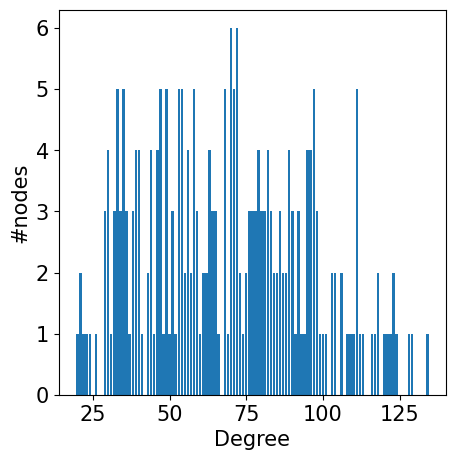

In [11]:
represent_degree_distribution(G_unweighted, scale='linear', rep='bars')

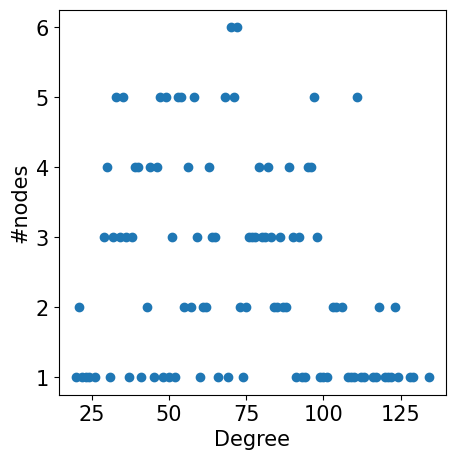

In [12]:
represent_degree_distribution(G_unweighted,scale='linear',rep='scatter',weight=False) 

/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_72295/2778416597.py:22: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


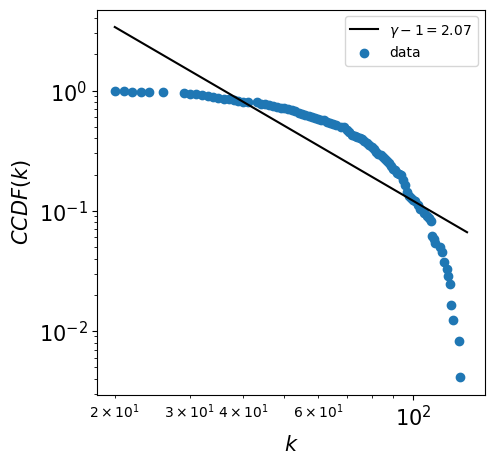

In [13]:
fit_CCDF(G_unweighted)

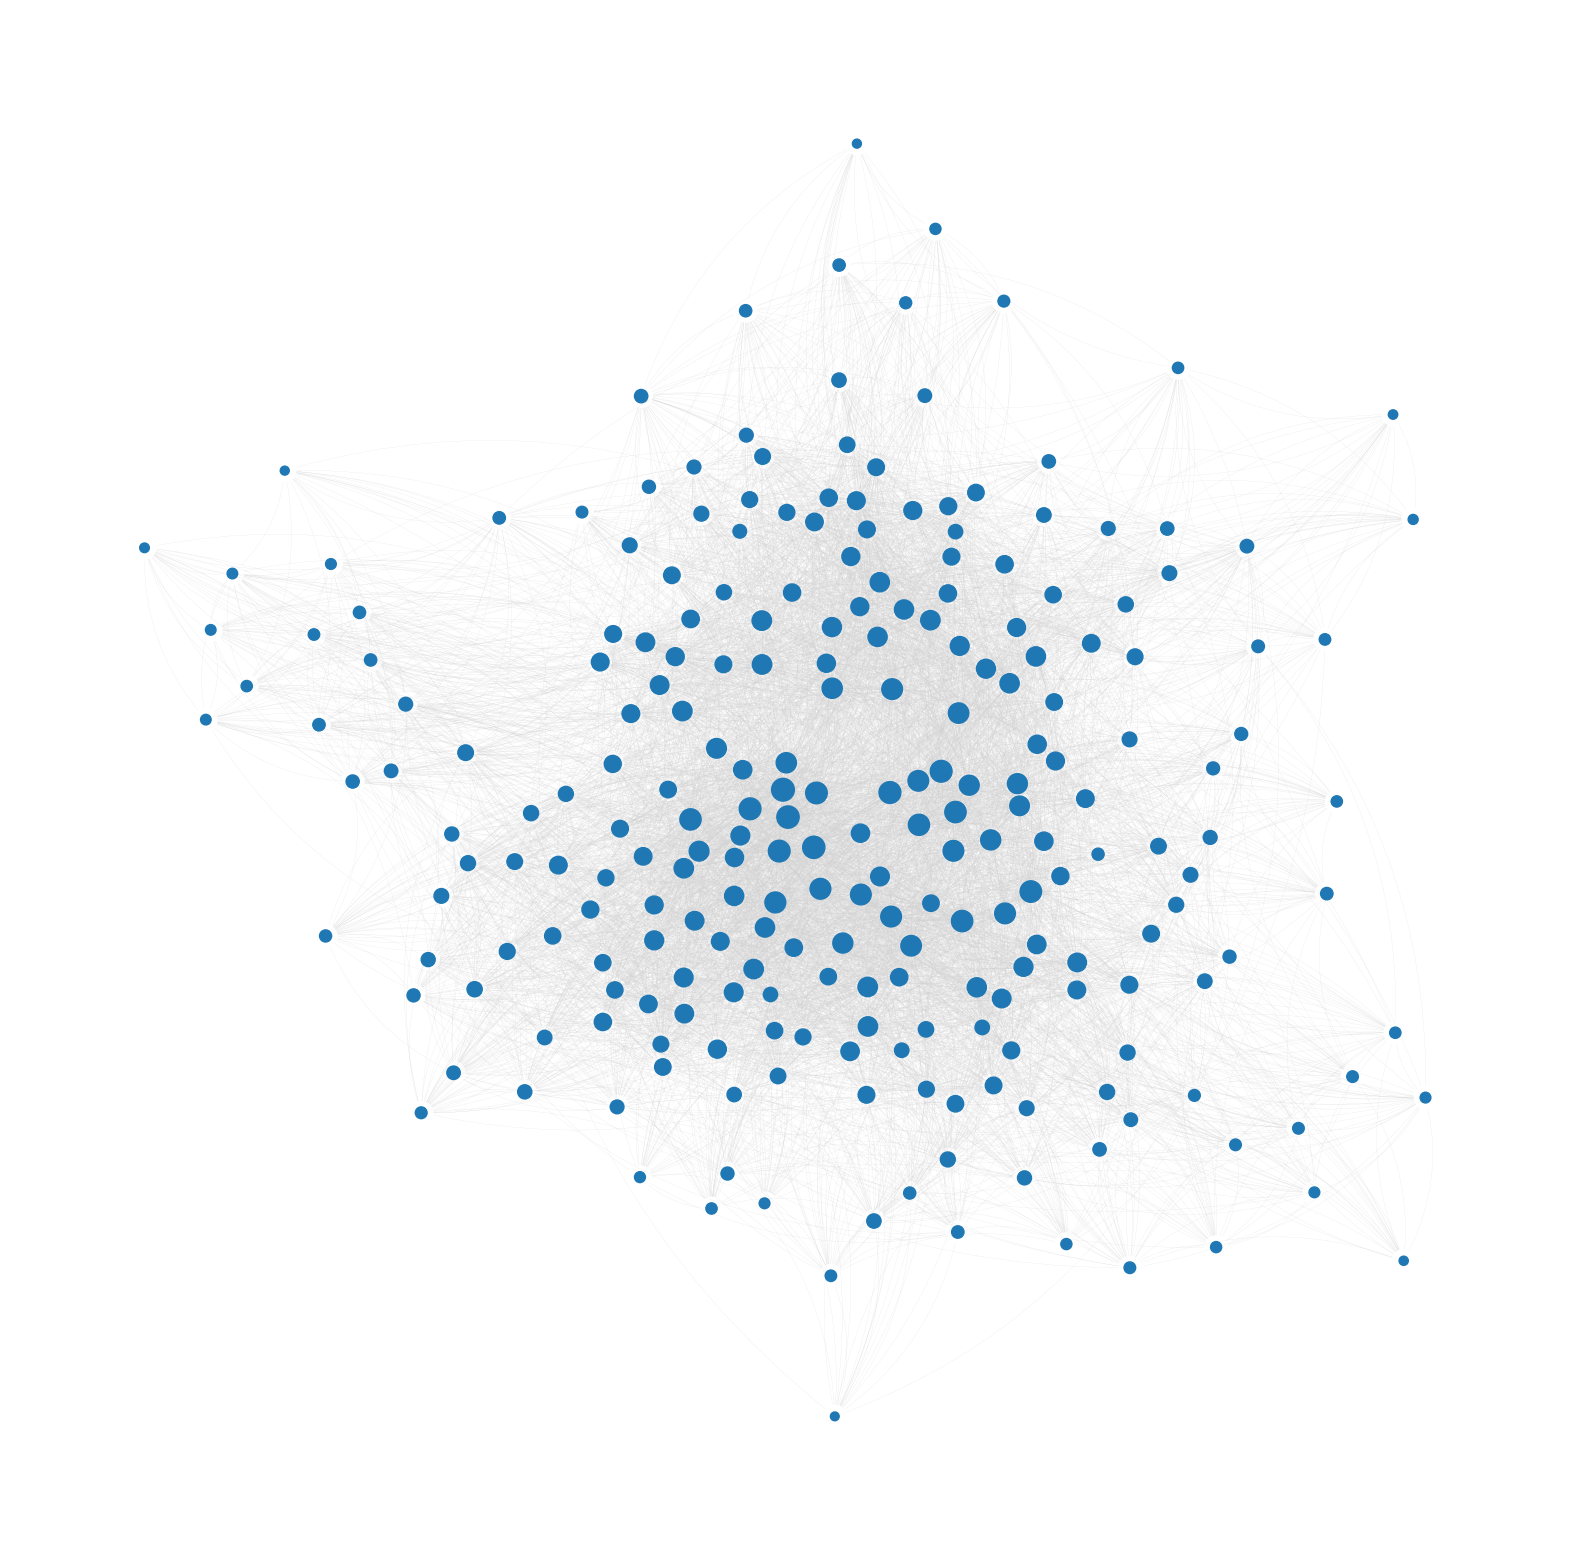

In [14]:
plot_network(G_unweighted)

In [15]:
G_multi = nx.read_pajek("A3_primary_school_network/primaryschool_w.net")

G_weighted = nx.Graph()
for u, v, data in G_multi.edges(data=True):
    weight = data.get('weight', 1)
    if G_weighted.has_edge(u, v):
        G_weighted[u][v]['weight'] += weight
    else:
        G_weighted.add_edge(u, v, weight=weight)

In [16]:
structural_characterization(G_weighted)

Number of nodes: 242
Number of edges: 8317
Minimum Degree: 20
Maximum Degree: 134
Average Degree: 68.74
Average Clustering Coefficient: 0.5255
Assortativity Coefficient (r): 0.1183
Average Shortest Path Length: 1.73
Diameter: 3
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


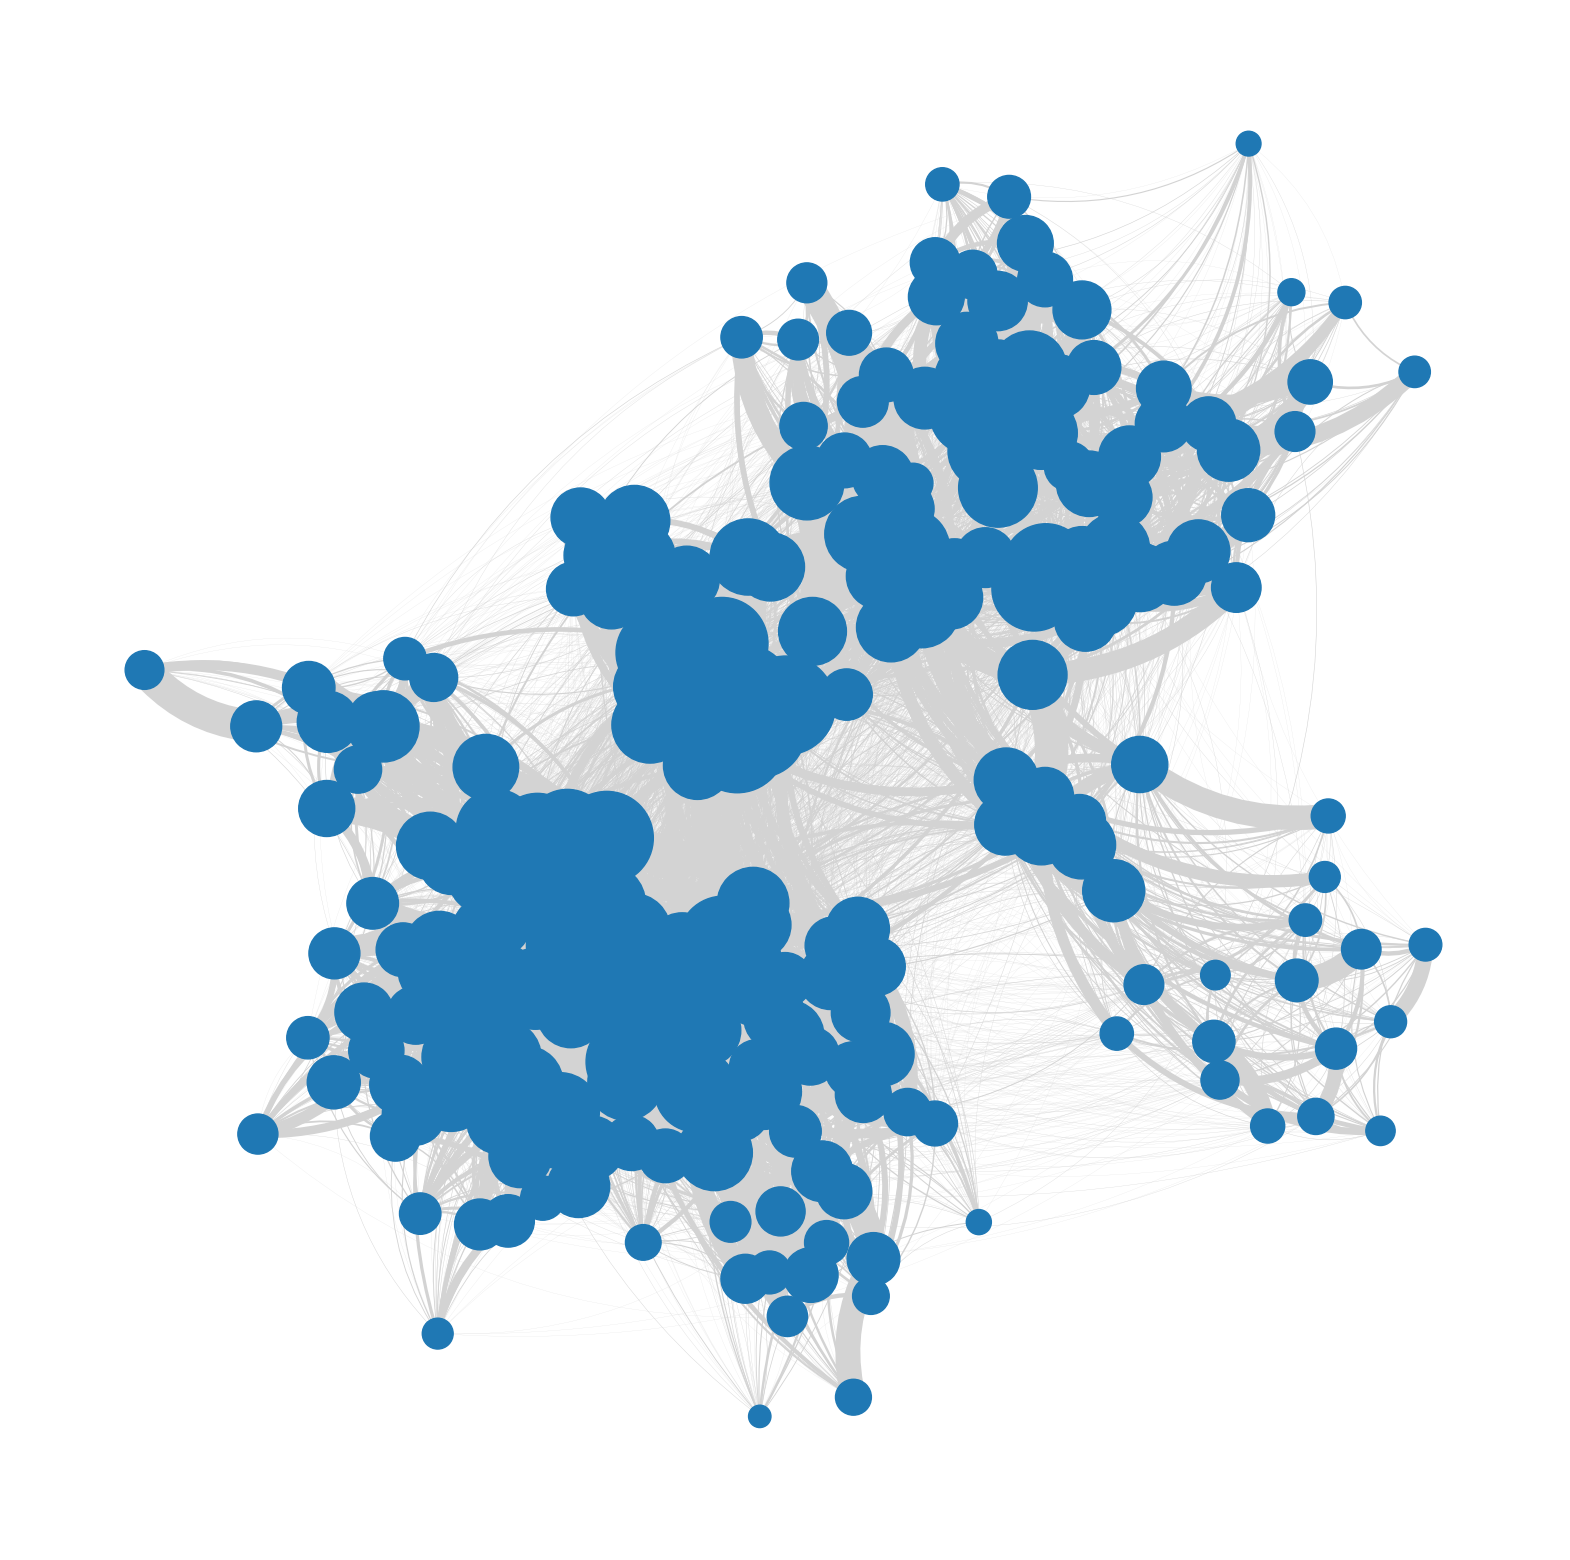

In [17]:
plot_network(G_weighted)

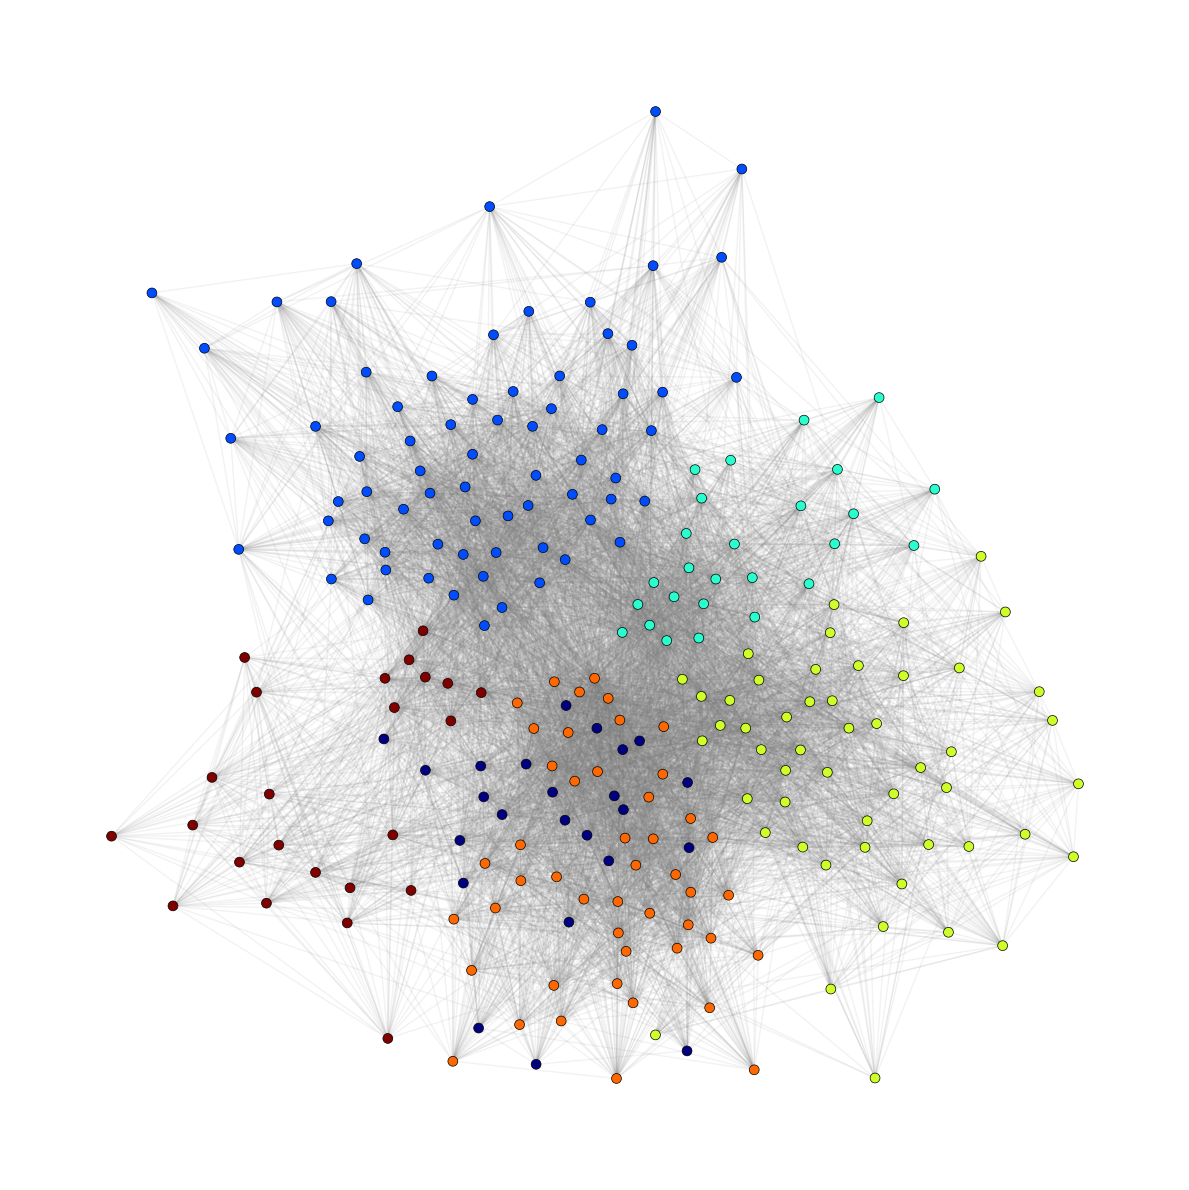

In [18]:
detect_communities('louvain', G_unweighted)

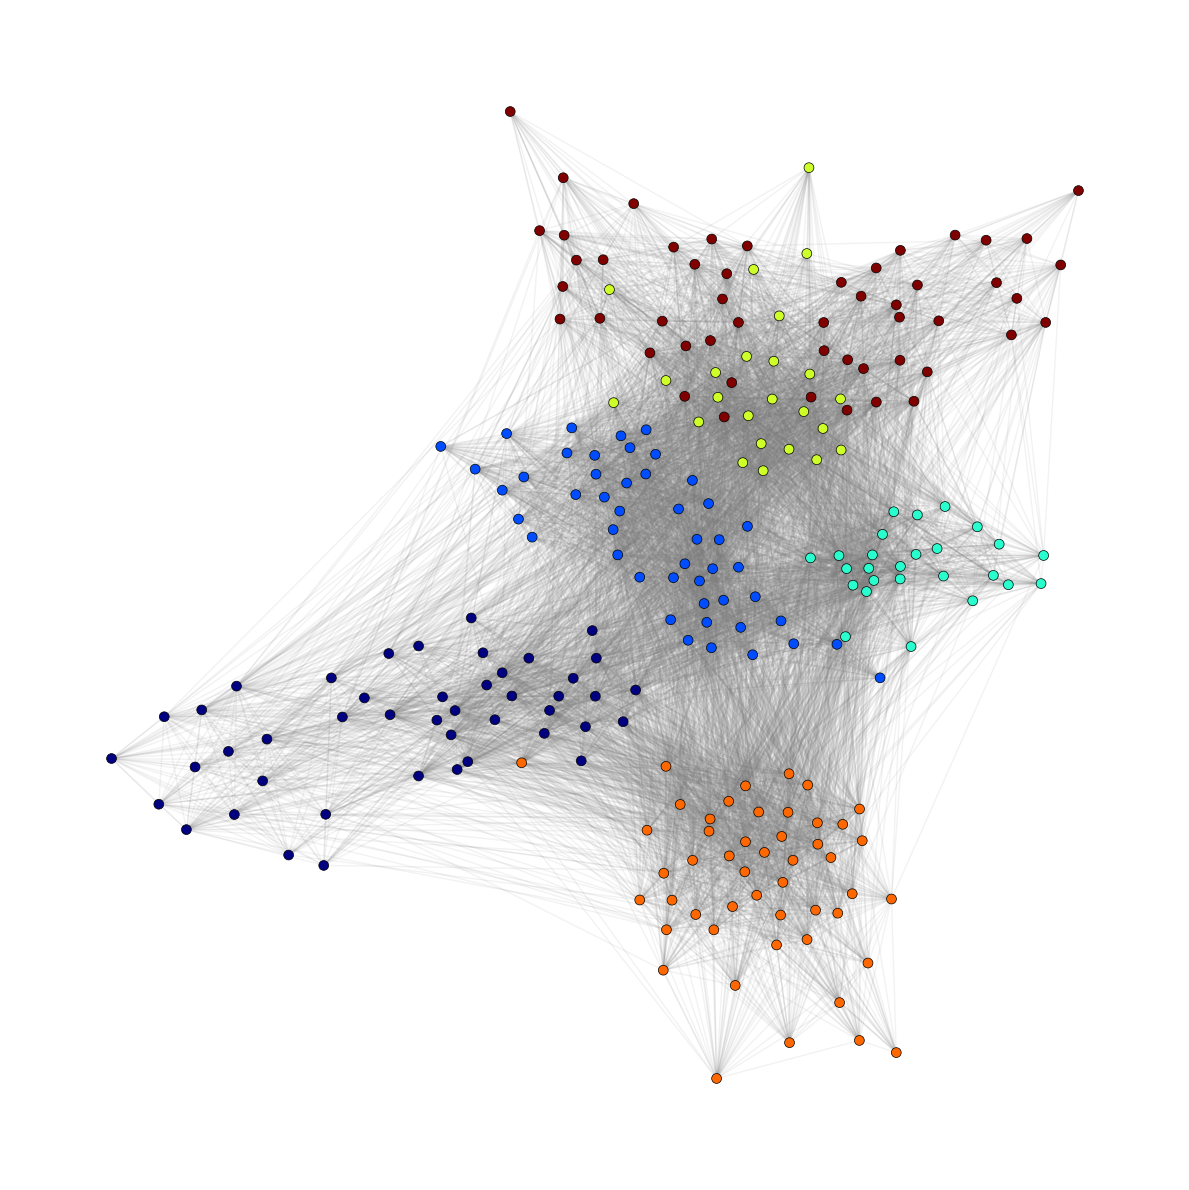

In [21]:
detect_communities('louvain', G_weighted)